<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
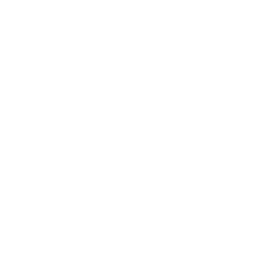
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Classification de l'efficacité énergétique des bâtiments</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Énergie / Analytique de durabilité &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Cet exemple pratique regroupe un portefeuille de bâtiments commerciaux selon cinq métriques d'efficacité énergétique — intensité d'utilisation énergétique (EUI), rapport d'efficacité CVC, résistance thermique de l'enveloppe, densité de puissance d'éclairage et pourcentage de compensation renouvelable — afin de faire apparaître des paliers de performance distincts pour cibler les remises des services publics. L'analyse utilise **PROC FASTCLUS** avec `REPLACE=FULL` (remplacement complet des graines) et compare les solutions k=3, 4, 5 et 6 sur le R² global, la statistique F pseudo et la taille minimale de grappe. La solution k=4 est ensuite profilée en détail et chaque grappe est associée à un palier d'efficacité exploitable. Comme cet environnement s'exécute sans licence, la démonstration se limite à un échantillon de 100 bâtiments ; le même programme s'adapte sans modification à un portefeuille complet.


## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Métriques annuelles d'efficacité énergétique par bâtiment (synthétique) | 100 |



---

In [1]:
/* --------------------------------------------------------
   Génération de métriques énergétiques synthétiques de bâtiments
   Indicateurs d'efficacité des bâtiments commerciaux
   -------------------------------------------------------- */
DONNÉES work.building_metrics;
    APPELER streaminit(42);
    LONGUEUR building_type $20 climate_region $15;
    FAIRE building_id = 1 JUSQU_À 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        SI type_idx = 1 ALORS building_type = 'BUREAU';
        SINON SI type_idx = 2 ALORS building_type = 'COMMERCE';
        SINON SI type_idx = 3 ALORS building_type = 'ENTREPÔT';
        SINON SI type_idx = 4 ALORS building_type = 'HÔPITAL';
        SINON building_type = 'ÉCOLE';

        reg_idx = int(rand('uniform') * 4) + 1;
        SI reg_idx = 1 ALORS climate_region = 'NORD_EST';
        SINON SI reg_idx = 2 ALORS climate_region = 'SUD_EST';
        SINON SI reg_idx = 3 ALORS climate_region = 'CENTRE_OUEST';
        SINON climate_region = 'OUEST';

        /* Energy Use Intensity (kBtu/sqft/yr) */
        eui = round(rand('normal', 85, 35), 0.1);
        SI eui < 15 ALORS eui = 15;
        SI eui > 250 ALORS eui = 250;

        /* HVAC efficiency ratio (COP equivalent) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        SI hvac_efficiency < 1.0 ALORS hvac_efficiency = 1.0;
        SI hvac_efficiency > 6.0 ALORS hvac_efficiency = 6.0;

        /* Envelope thermal resistance (R-value) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        SI envelope_r_value < 5 ALORS envelope_r_value = 5;
        SI envelope_r_value > 40 ALORS envelope_r_value = 40;

        /* Lighting power density (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        SI lighting_wpf < 0.3 ALORS lighting_wpf = 0.3;
        SI lighting_wpf > 2.5 ALORS lighting_wpf = 2.5;

        /* Renewable energy offset percentage */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        SI renewable_pct > 80 ALORS renewable_pct = 80;

        /* Building age in years */
        building_age = int(rand('uniform') * 80) + 1;

        /* Floor area (thousands of sqft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        SI floor_area_ksf > 500 ALORS floor_area_ksf = 500;

        SORTIE;
    FIN;
    SUPPRIMER type_idx reg_idx;
EXÉCUTER;



NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.84 seconds
  cpu   1.84 seconds


---

In [2]:
/* --------------------------------------------------------
   Distributions de référence des métriques énergétiques par
   type de bâtiment
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.building_metrics n mean std;
    CLASSE building_type;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ÉTIQUETTE building_type="Type de bâtiment" eui="Intensité d'utilisation énergétique (EUI)"
        hvac_efficiency="Efficacité CVC (COP)" envelope_r_value="Résistance thermique de l'enveloppe (R)"
        lighting_wpf="Densité de puissance d'éclairage (W/sqft)" renewable_pct="Compensation renouvelable (%)";
    TITRE 'Métriques énergétiques par type de bâtiment';
EXÉCUTER;


                                      Métriques énergétiques par type de bâtiment                                       

                                                  The MEANS Procedure

                          Analysis Variable : eui Intensité d'utilisation énergétique (EUI)

        Type de bâtiment           N Obs           Mean        Std Dev
        --------------------------------------------------------------
        BUREAU                        20     73.0550000     40.3950163
        COMMERCE                      16     79.7312500     42.6818106
        ENTREPÔT                      20     90.8900000     33.5993249
        HÔPITAL                       25     87.9040000     35.2632892
        ÉCOLE                         19     89.7000000     39.0498542
        --------------------------------------------------------------

                               Analysis Variable : hvac_efficiency Efficacité CVC (COP)

        Type de bâtiment           N Obs           Mean 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                      Métriques énergétiques par type de bâtiment                                       




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


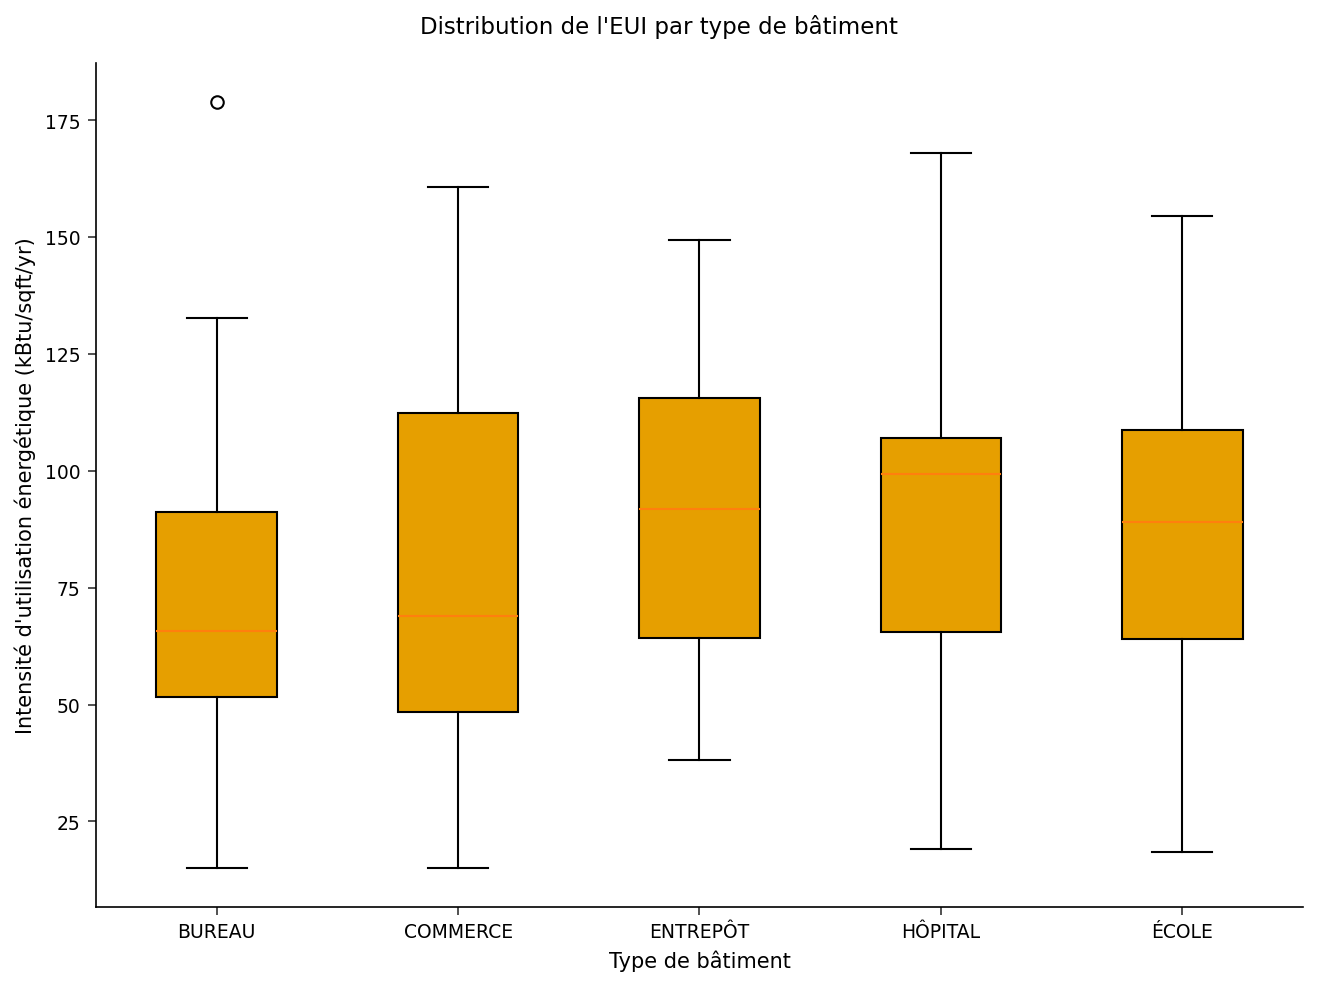

In [3]:
/* --------------------------------------------------------
   Distribution de l'EUI par type de bâtiment
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS ÉTIQUETTE='Type de bâtiment';
    YAXIS ÉTIQUETTE="Intensité d'utilisation énergétique (kBtu/sqft/yr)";
    TITRE "Distribution de l'EUI par type de bâtiment";
EXÉCUTER;


---

In [4]:
/* --------------------------------------------------------
   Standardisation des métriques d'efficacité
   -------------------------------------------------------- */
PROCÉDURE standard DONNÉES=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
EXÉCUTER;



NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   Classification k-means : k=3 avec REPLACE=FULL
   -------------------------------------------------------- */
PROCÉDURE FASTCLUS DONNÉES=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REMPLACER=COMPLET
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ÉTIQUETTE eui="Intensité d'utilisation énergétique (EUI)"
        hvac_efficiency="Efficacité CVC (COP)" envelope_r_value="Résistance thermique de l'enveloppe (R)"
        lighting_wpf="Densité de puissance d'éclairage (W/sqft)" renewable_pct="Compensation renouvelable (%)";
    TITRE "Classification de l'efficacité des bâtiments : k=3 REPLACE=FULL";
EXÉCUTER;


                                      Métriques énergétiques par type de bâtiment                                       


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   Classification k-means : k=4 avec REPLACE=FULL
   -------------------------------------------------------- */
PROCÉDURE FASTCLUS DONNÉES=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REMPLACER=COMPLET
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ÉTIQUETTE eui="Intensité d'utilisation énergétique (EUI)"
        hvac_efficiency="Efficacité CVC (COP)" envelope_r_value="Résistance thermique de l'enveloppe (R)"
        lighting_wpf="Densité de puissance d'éclairage (W/sqft)" renewable_pct="Compensation renouvelable (%)";
    TITRE "Classification de l'efficacité des bâtiments : k=4 REPLACE=FULL";
EXÉCUTER;


                                      Métriques énergétiques par type de bâtiment                                       


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   Classification k-means : k=5 avec REPLACE=FULL
   -------------------------------------------------------- */
PROCÉDURE FASTCLUS DONNÉES=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REMPLACER=COMPLET
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ÉTIQUETTE eui="Intensité d'utilisation énergétique (EUI)"
        hvac_efficiency="Efficacité CVC (COP)" envelope_r_value="Résistance thermique de l'enveloppe (R)"
        lighting_wpf="Densité de puissance d'éclairage (W/sqft)" renewable_pct="Compensation renouvelable (%)";
    TITRE "Classification de l'efficacité des bâtiments : k=5 REPLACE=FULL";
EXÉCUTER;


                                      Métriques énergétiques par type de bâtiment                                       


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   Classification k-means : k=6 avec REPLACE=FULL
   -------------------------------------------------------- */
PROCÉDURE FASTCLUS DONNÉES=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REMPLACER=COMPLET
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ÉTIQUETTE eui="Intensité d'utilisation énergétique (EUI)"
        hvac_efficiency="Efficacité CVC (COP)" envelope_r_value="Résistance thermique de l'enveloppe (R)"
        lighting_wpf="Densité de puissance d'éclairage (W/sqft)" renewable_pct="Compensation renouvelable (%)";
    TITRE "Classification de l'efficacité des bâtiments : k=6 REPLACE=FULL";
EXÉCUTER;


                                      Métriques énergétiques par type de bâtiment                                       


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Comparaison de la qualité des grappes pour k=3 à 6
   Calcul du R² intra-grappe et de la taille minimale de grappe
   -------------------------------------------------------- */
%macro cluster_quality(k);
PROCÉDURE FRÉQUENCES DONNÉES=work.bldg_clust&k SANS_IMPRESSION;
    TABLES cluster / out=work.freq_k&k (RENOMMER=(count=n_buildings));
EXÉCUTER;

PROCÉDURE sql SANS_IMPRESSION;
    SÉLECTIONNER MIN(n_buildings) VERS :min_size_k&k
    DEPUIS work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);


                                      Métriques énergétiques par type de bâtiment                                       

                                      Métriques énergétiques par type de bâtiment                                       

                                      Métriques énergétiques par type de bâtiment                                       

                                      Métriques énergétiques par type de bâtiment                                       




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                  Profils des paliers d'efficacité des bâtiments (k=4)                                  

                                                  The MEANS Procedure

                                     Analysis Variable : eui Intensité d'utilisation énergétique (EUI)

                                                 N
                                     Grappe    Obs             Mean         Std Dev
                                     ----------------------------------------------
                                     1          23       63.7782609      31.5423086
                                     2          17      122.5941176      36.0679995
                                     3          26       94.0076923      30.8825378
                                     4          34       72.3911765      31.7411154
                                     ----------------------------------------------

                                      Analysis Variable : hvac_


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


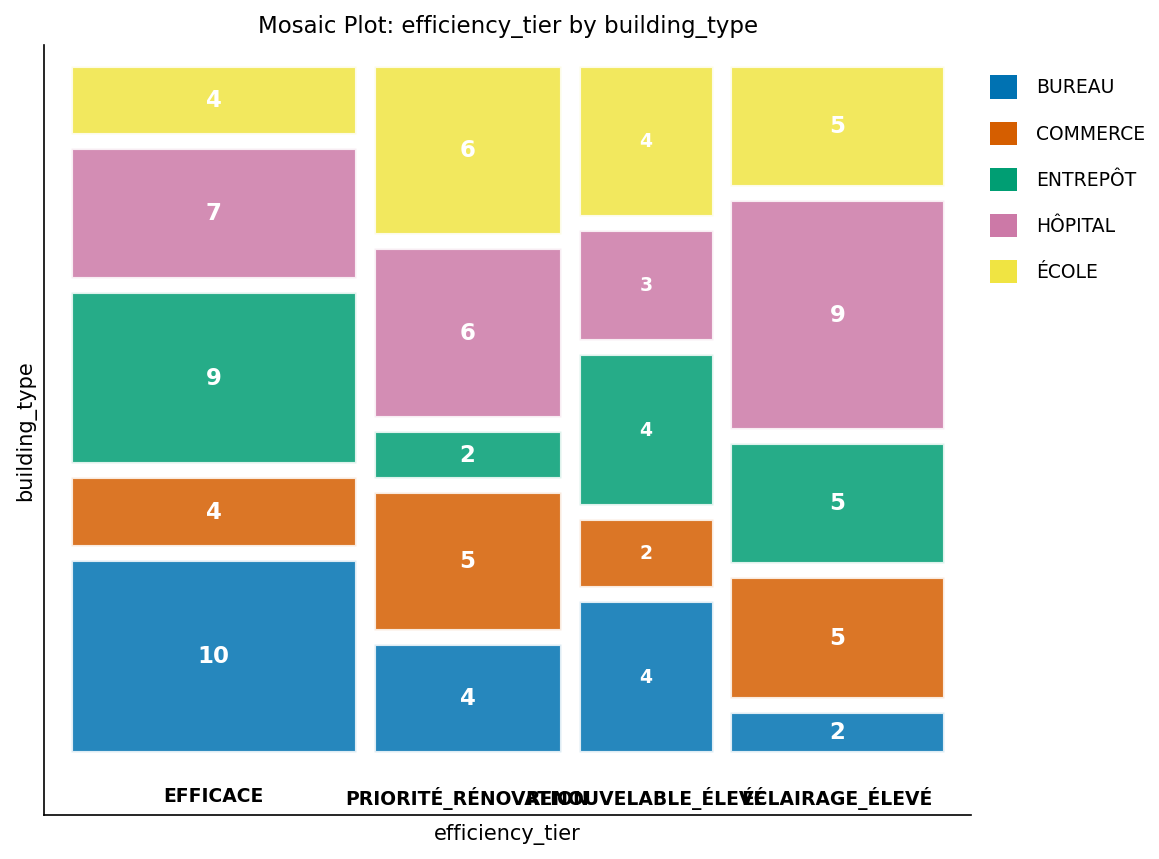

In [10]:
/* --------------------------------------------------------
   Profilage de la solution k=4 retenue
   -------------------------------------------------------- */
DONNÉES work.bldg_profiled;
    FUSIONNER work.building_metrics
          work.bldg_clust4 (GARDER=building_id cluster distance);
    PAR building_id;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=work.bldg_profiled mean std;
    CLASSE cluster;
    VAR eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    ÉTIQUETTE cluster="Grappe" eui="Intensité d'utilisation énergétique (EUI)"
        hvac_efficiency="Efficacité CVC (COP)" envelope_r_value="Résistance thermique de l'enveloppe (R)"
        lighting_wpf="Densité de puissance d'éclairage (W/sqft)" renewable_pct="Compensation renouvelable (%)"
        building_age="Âge du bâtiment (années)";
    TITRE "Profils des paliers d'efficacité des bâtiments (k=4)";
EXÉCUTER;

/* Étiqueter les paliers d'efficacité à partir des centroïdes k=4 observés :
   Grappe 4 = meilleur CVC (3,89) à faible EUI -> EFFICACE
   Grappe 2 = plus forte compensation renouvelable (28 %) mais EUI le plus élevé -> RENOUVELABLE_ÉLEVÉ
   Grappe 3 = charge d'éclairage la plus forte, CVC faible, EUI moyen -> ÉCLAIRAGE_ÉLEVÉ
   Grappe 1 = EUI faible mais CVC le plus faible + enveloppe la plus mince -> PRIORITÉ_RÉNOVATION */
DONNÉES work.bldg_tiered;
    DÉFINIR work.bldg_profiled;
    LONGUEUR efficiency_tier $30;
    SI cluster = 4 ALORS efficiency_tier = 'EFFICACE';
    SINON SI cluster = 2 ALORS efficiency_tier = 'RENOUVELABLE_ÉLEVÉ';
    SINON SI cluster = 3 ALORS efficiency_tier = 'ÉCLAIRAGE_ÉLEVÉ';
    SINON SI cluster = 1 ALORS efficiency_tier = 'PRIORITÉ_RÉNOVATION';
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    ÉTIQUETTE efficiency_tier="Palier d'efficacité" building_type="Type de bâtiment";
    TITRE "Palier d'efficacité par type de bâtiment";
EXÉCUTER;


---

### Interprétation

Avec `REPLACE=FULL`, chaque valeur de k a convergé proprement. Sur les quatre solutions, le R² global augmente de façon monotone avec k — 0,305 (k=3), 0,410 (k=4), 0,459 (k=5), 0,515 (k=6) — tandis que la statistique F pseudo culmine à **k=4 (22,23)** avant de décliner (20,13 à k=5, 19,93 à k=6). Combinée à une taille minimale de grappe de 17 bâtiments à k=4 (contre 13 à k=5 et 10 à k=6), la **solution k=4** offre le meilleur compromis entre séparation et stabilité des paliers ; elle est donc profilée ci-dessous.

Les quatre grappes de la solution k=4 correspondent à des profils d'efficacité clairement distincts (moyennes issues du profil PROC MEANS ci-dessus) :

- **Efficace (Grappe 4, n=34) :** le groupe le mieux équipé — la meilleure efficacité CVC (COP 3,89) à un EUI faible à modéré de 72,4 kBtu/sqft/yr, avec une enveloppe adéquate (R 18,8) et une compensation renouvelable modeste (11,0 %).
- **Forte part renouvelable (Grappe 2, n=17) :** les plus gros consommateurs en valeur absolue (EUI 122,6) mais aussi de loin la plus forte compensation renouvelable (28,2 %), avec un CVC intermédiaire (COP 3,42). Une forte consommation associée à une production sur site.
- **Éclairage intensif (Grappe 3, n=26) :** EUI intermédiaire (94,0) tiré par la plus forte densité de puissance d'éclairage (1,35 W/sqft) et le deuxième CVC le plus faible (COP 2,42), malgré l'enveloppe la plus épaisse (R 19,6).
- **Priorité de rénovation (Grappe 1, n=23) :** EUI faible sur le papier (63,8) mais le CVC le plus faible (COP 2,28) et l'enveloppe la plus mince (R 12,5) — des bâtiments petits ou peu utilisés mais mal équipés, les candidats les plus évidents pour des rénovations d'enveloppe et de CVC.

Le tableau croisé palier × type de bâtiment montre que les bureaux (10) et les entrepôts (9) dominent le palier efficace, tandis que les hôpitaux se concentrent dans le palier éclairage intensif (9 sur 26). Le palier priorité de rénovation est réparti entre les types, mené par les hôpitaux et les écoles (6 chacun sur 23). Pour la conception des programmes, les 23 bâtiments en priorité de rénovation et les 26 en éclairage intensif sont les cibles naturelles des incitations CVC et éclairage respectivement, tandis que les 17 bâtiments à forte part renouvelable — qui produisent déjà sur site — se prêtent mieux à la réduction de la demande qu'à de nouvelles remises pour la production.


---

In [11]:
/* --------------------------------------------------------
   Exportation des paliers d'efficacité des bâtiments et des
   profils de centroïdes
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;



NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>